## Redondo precipitation to dicharge analysis

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

lajara_2021 = pd.read_csv("la_jara/discharge_2021.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # first column is datetime and second column is discharge in m3/s
lajara_2022 = pd.read_csv("la_jara/discharge_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
lajara_2023 = pd.read_csv("la_jara/discharge_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
redondo_dicharge = pd.read_csv("redondo/DataSetExport-Discharge.Discharge@VALL_MIRLKE-Maximum-ft^3 s-20260223140410.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
redondo = pd.read_csv('redondo_airtemp_pcp.csv', parse_dates=[0], index_col=0, na_values=['NaN']) 
redondo.index = pd.to_datetime(redondo.index, format='%m/%d/%Y', errors='coerce')
redondo = redondo[redondo.index.notna()]  # remove rows with invalid dates
redondo = redondo.replace(-9999, np.nan) # replace -9999 with NaN 

Find max and avg daily dicharge values

In [78]:
# find max and average daily discharge 
redondo_daily_discharge = pd.DataFrame(index=redondo_dicharge.resample('D').max().index)
redondo_daily_discharge['redondo_max'] = redondo_dicharge.resample('D').max()
redondo_daily_discharge['redondo_avg'] = redondo_dicharge.resample('D').mean()

# la jara 
# 2021
lajara2021_daily_discharge = pd.DataFrame(index=lajara_2021.resample('D').max().index)
lajara2021_daily_discharge['lajara_max'] = lajara_2021.resample('D').max()
lajara2021_daily_discharge['lajara_avg'] = lajara_2021.resample('D').mean()
# 2022
lajara2022_daily_discharge = pd.DataFrame(index=lajara_2022.resample('D').max().index)
lajara2022_daily_discharge['lajara_max'] = lajara_2022.resample('D').max()
lajara2022_daily_discharge['lajara_avg'] = lajara_2022.resample('D').mean()
# 2023
lajara2023_daily_discharge = pd.DataFrame(index=lajara_2023.resample('D').max().index)
lajara2023_daily_discharge['lajara_max'] = lajara_2023.resample('D').max()
lajara2023_daily_discharge['lajara_avg'] = lajara_2023.resample('D').mean()

lajara_daily_discharge = pd.concat([lajara2021_daily_discharge, lajara2022_daily_discharge, lajara2023_daily_discharge])


In [79]:
lajara_daily_discharge

,lajara_max,lajara_avg
Date_Time,,
2021-07-01,0.095593,0.015596
2021-07-02,0.016571,0.008561
2021-07-03,0.008675,0.006644
2021-07-04,0.005847,0.005425
2021-07-05,0.006227,0.005332
...,...,...
2023-09-13,0.006616,0.004470
2023-09-14,0.028418,0.007838
2023-09-15,0.010190,0.005385


In [80]:
redondo

,avg_temp,max_temp,min_temp,avg_snow,total_precip
Date,,,,,
2021-06-01,46.2,58.8,36.9,-2.42,0.09
2021-06-02,47.4,58.0,37.9,-2.09,0.00
2021-06-03,49.7,65.1,41.4,-2.42,0.13
2021-06-04,54.2,68.4,39.4,-2.62,0.04
2021-06-05,56.0,71.0,48.0,-2.48,0.02
...,...,...,...,...,...
2023-09-27,54.3,63.5,46.1,-1.88,0.00
2023-09-28,53.6,62.5,46.7,-1.78,0.00
2023-09-29,52.5,63.1,44.7,-1.77,0.00


Merge precipitation data to discharge dataframes

In [81]:
# merge precipitation data to the dicharge dataframes
lajara_daily = lajara_daily_discharge.merge(redondo, left_index=True, right_index=True)
redondo_daily  = redondo_daily_discharge.merge(redondo, left_index=True, right_index=True)

In [82]:
lajara_daily

,lajara_max,lajara_avg,avg_temp,max_temp,min_temp,avg_snow,total_precip
2021-07-01,0.095593,0.015596,51.9,63.1,43.0,6.24,0.59
2021-07-02,0.016571,0.008561,53.7,68.0,47.3,0.23,0.46
2021-07-03,0.008675,0.006644,56.8,70.2,47.2,-0.86,0.04
2021-07-04,0.005847,0.005425,59.7,71.3,51.9,-1.69,0.03
2021-07-05,0.006227,0.005332,55.6,65.2,48.7,-2.21,0.37
...,...,...,...,...,...,...,...
2023-09-13,0.006616,0.004470,44.7,53.1,38.2,17.15,0.23
2023-09-14,0.028418,0.007838,43.0,53.4,36.8,10.26,0.74
2023-09-15,0.010190,0.005385,43.2,51.0,37.5,-1.73,0.03
2023-09-16,0.006135,0.004440,45.1,55.1,36.3,0.07,0.00


### Time series plots

2021

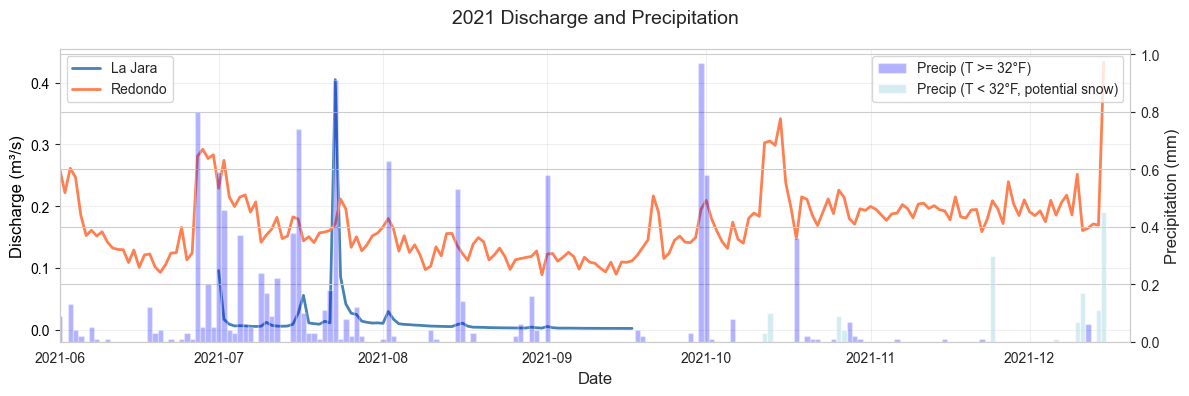

In [101]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# filter 2021 data
data_2021_lajara = lajara_daily[lajara_daily.index.year == 2021]
data_2021_redondo = redondo_daily[redondo_daily.index.year == 2021]

# plot discharge on left y-axis
ax1.plot(data_2021_lajara.index, data_2021_lajara['lajara_max'], label='La Jara', linewidth=2, color='steelblue')
ax1.plot(data_2021_redondo.index, data_2021_redondo['redondo_max'], label='Redondo', linewidth=2, color='coral')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Discharge (m³/s)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1))


# create second y-axis for precipitation
ax2 = ax1.twinx()

# combine precipitation from both sources using combine_first (includes all dates from both)
precip_combined = data_2021_lajara['total_precip'].combine_first(data_2021_redondo['total_precip'])
temp_combined = data_2021_lajara['avg_temp'].combine_first(data_2021_redondo['avg_temp'])

# separate precipitation by temperature
precip_warm = precip_combined.where(temp_combined >= 32, 0)
precip_cold = precip_combined.where(temp_combined < 32, 0)

# plot both
ax2.bar(precip_combined.index, precip_warm, alpha=0.3, label='Precip (T >= 32°F)', color='blue', width=1)
ax2.bar(precip_combined.index, precip_cold, alpha=0.5, label='Precip (T < 32°F, potential snow)', color='lightblue', width=1)
ax2.set_ylabel('Precipitation (mm)', fontsize=12)
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))

fig.suptitle('2021 Discharge and Precipitation', fontsize=14)
plt.xlim(pd.to_datetime('06-01-2021'), pd.to_datetime('12-20-2021'))
plt.tight_layout()
plt.show()

Time seried in 2022

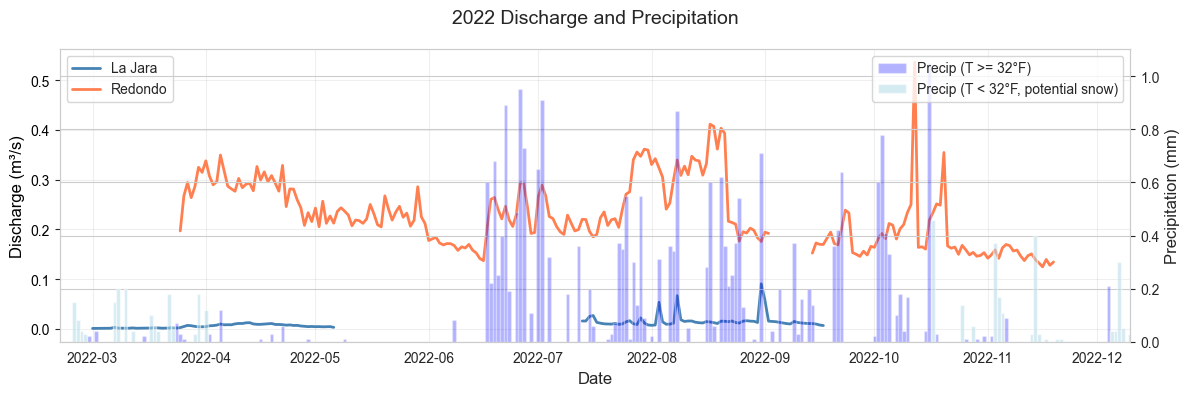

In [100]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# filter 2022 data
data_2022_lajara = lajara_daily[lajara_daily.index.year == 2022]
data_2022_redondo = redondo_daily[redondo_daily.index.year == 2022]

# plot discharge on left y-axis
ax1.plot(data_2022_lajara.index, data_2022_lajara['lajara_max'], label='La Jara', linewidth=2, color='steelblue')
ax1.plot(data_2022_redondo.index, data_2022_redondo['redondo_max'], label='Redondo', linewidth=2, color='coral')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Discharge (m³/s)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1))


# create second y-axis for precipitation
ax2 = ax1.twinx()

# combine precipitation from both sources using combine_first (includes all dates from both)
precip_combined = data_2022_lajara['total_precip'].combine_first(data_2022_redondo['total_precip'])
temp_combined = data_2022_lajara['avg_temp'].combine_first(data_2022_redondo['avg_temp'])

# separate precipitation by temperature
precip_warm = precip_combined.where(temp_combined >= 32, 0)
precip_cold = precip_combined.where(temp_combined < 32, 0)

# plot both
ax2.bar(precip_combined.index, precip_warm, alpha=0.3, label='Precip (T >= 32°F)', color='blue', width=1)
ax2.bar(precip_combined.index, precip_cold, alpha=0.5, label='Precip (T < 32°F, potential snow)', color='lightblue', width=1)
ax2.set_ylabel('Precipitation (mm)', fontsize=12)
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))

fig.suptitle('2022 Discharge and Precipitation', fontsize=14)
plt.xlim(pd.to_datetime('02-20-2022'), pd.to_datetime('12-10-2022'))
plt.tight_layout()
plt.show()

Time series in 2023

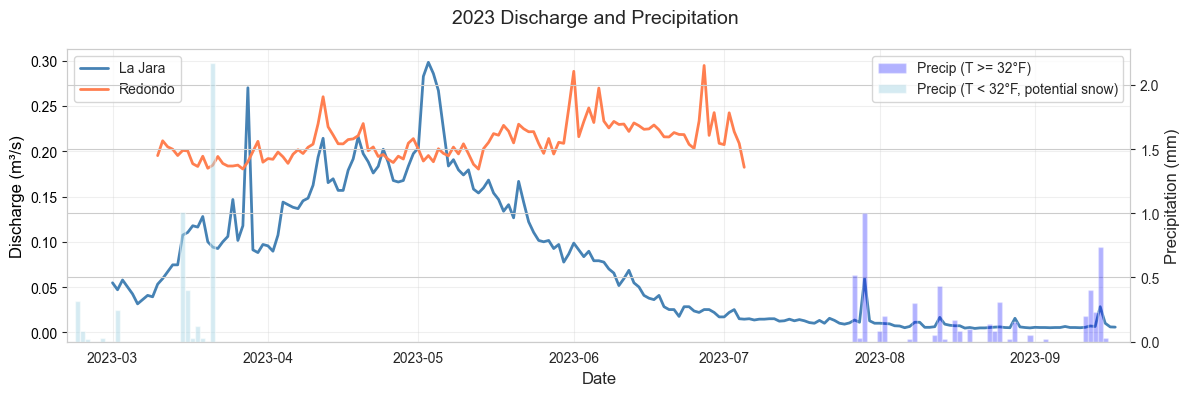

In [98]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# filter 2023 data
data_2023_lajara = lajara_daily[lajara_daily.index.year == 2023]
data_2023_redondo = redondo_daily[redondo_daily.index.year == 2023]

# plot discharge on left y-axis
ax1.plot(data_2023_lajara.index, data_2023_lajara['lajara_max'], label='La Jara', linewidth=2, color='steelblue')
ax1.plot(data_2023_redondo.index, data_2023_redondo['redondo_max'], label='Redondo', linewidth=2, color='coral')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Discharge (m³/s)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1))


# create second y-axis for precipitation
ax2 = ax1.twinx()

# combine precipitation from both sources using combine_first (includes all dates from both)
precip_combined = data_2023_lajara['total_precip'].combine_first(data_2023_redondo['total_precip'])
temp_combined = data_2023_lajara['avg_temp'].combine_first(data_2023_redondo['avg_temp'])

# separate precipitation by temperature
precip_warm = precip_combined.where(temp_combined >= 32, 0)
precip_cold = precip_combined.where(temp_combined < 32, 0)

# plot both
ax2.bar(precip_combined.index, precip_warm, alpha=0.3, label='Precip (T >= 32°F)', color='blue', width=1)
ax2.bar(precip_combined.index, precip_cold, alpha=0.5, label='Precip (T < 32°F, potential snow)', color='lightblue', width=1)
ax2.set_ylabel('Precipitation (mm)', fontsize=12)
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))

fig.suptitle('2023 Discharge and Precipitation', fontsize=14)
plt.xlim(pd.to_datetime('02-20-2023'), pd.to_datetime('09-20-2023'))
plt.tight_layout()
plt.show()

### Plot discharges to precipitations

Average Q - Total PCP 

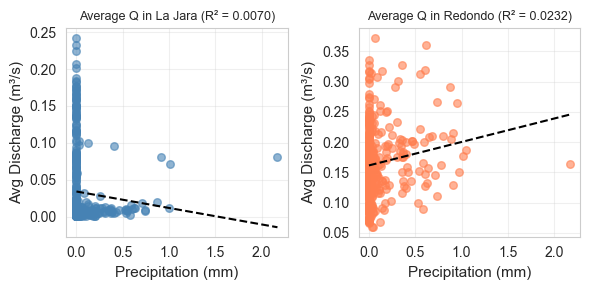

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
sns.set_style("whitegrid")

# La Jara
valid_lajara = lajara_daily[['lajara_avg', 'total_precip']].dropna()  # adjust column name as needed
ax = axes[0]
ax.scatter(valid_lajara['total_precip'], valid_lajara['lajara_avg'], alpha=0.6, s=30, color='steelblue')
slope, intercept, r_value, p_value, std_err = linregress(valid_lajara['total_precip'], valid_lajara['lajara_avg'])
x_line = np.array([valid_lajara['total_precip'].min(), valid_lajara['total_precip'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Avg Discharge (m³/s)', fontsize=11)
ax.set_title(f'Average Q in La Jara (R² = {r_value**2:.4f})', fontsize=9)
ax.grid(True, alpha=0.3)

# Redondo
valid_redondo = redondo_daily[['redondo_avg', 'total_precip']].dropna()  # adjust column name as needed
ax = axes[1]
ax.scatter(valid_redondo['total_precip'], valid_redondo['redondo_avg'], alpha=0.6, s=30, color='coral')
slope, intercept, r_value, p_value, std_err = linregress(valid_redondo['total_precip'], valid_redondo['redondo_avg'])
x_line = np.array([valid_redondo['total_precip'].min(), valid_redondo['total_precip'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Avg Discharge (m³/s)', fontsize=11)
ax.set_title(f'Average Q in Redondo (R² = {r_value**2:.4f})', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Average Q - Total PCP (excluding PCP=0)

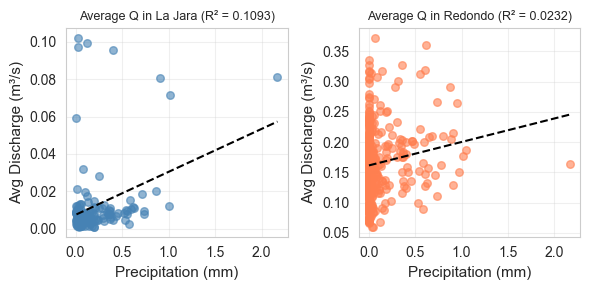

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
sns.set_style("whitegrid")

# La Jara
valid_lajara = lajara_daily[['lajara_avg', 'total_precip']].dropna()  #
valid_lajara = valid_lajara[valid_lajara['total_precip'] > 0]  # exclude zero precip
ax = axes[0]
ax.scatter(valid_lajara['total_precip'], valid_lajara['lajara_avg'], alpha=0.6, s=30, color='steelblue')
slope, intercept, r_value, p_value, std_err = linregress(valid_lajara['total_precip'], valid_lajara['lajara_avg'])
x_line = np.array([valid_lajara['total_precip'].min(), valid_lajara['total_precip'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Avg Discharge (m³/s)', fontsize=11)
ax.set_title(f'Average Q in La Jara (R² = {r_value**2:.4f})', fontsize=9)
ax.grid(True, alpha=0.3)

# Redondo
valid_redondo = redondo_daily[['redondo_avg', 'total_precip']].dropna()  
valid_lajara = valid_lajara[valid_lajara['total_precip'] > 0]  # exclude zero precip
ax = axes[1]
ax.scatter(valid_redondo['total_precip'], valid_redondo['redondo_avg'], alpha=0.6, s=30, color='coral')
slope, intercept, r_value, p_value, std_err = linregress(valid_redondo['total_precip'], valid_redondo['redondo_avg'])
x_line = np.array([valid_redondo['total_precip'].min(), valid_redondo['total_precip'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Avg Discharge (m³/s)', fontsize=11)
ax.set_title(f'Average Q in Redondo (R² = {r_value**2:.4f})', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Max Q - Total PCP 

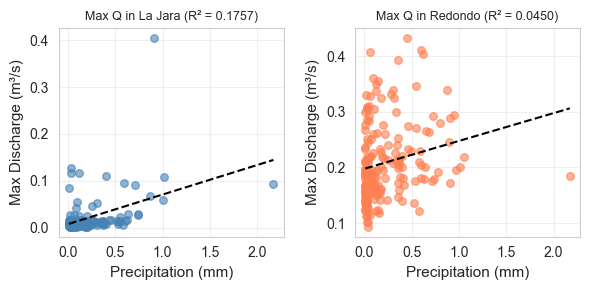

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
sns.set_style("whitegrid")

# La Jara
valid_lajara = lajara_daily[['lajara_max', 'total_precip']].dropna()  
valid_lajara = valid_lajara[valid_lajara['total_precip'] > 0]  # exclude zero precip
ax = axes[0]
ax.scatter(valid_lajara['total_precip'], valid_lajara['lajara_max'], alpha=0.6, s=30, color='steelblue')
slope, intercept, r_value, p_value, std_err = linregress(valid_lajara['total_precip'], valid_lajara['lajara_max'])
x_line = np.array([valid_lajara['total_precip'].min(), valid_lajara['total_precip'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Max Discharge (m³/s)', fontsize=11)
ax.set_title(f'Max Q in La Jara (R² = {r_value**2:.4f})', fontsize=9)
ax.grid(True, alpha=0.3)

# Redondo
valid_redondo = redondo_daily[['redondo_max', 'total_precip']].dropna()  
valid_redondo = valid_redondo[valid_redondo['total_precip'] > 0]  # exclude zero precip
ax = axes[1]
ax.scatter(valid_redondo['total_precip'], valid_redondo['redondo_max'], alpha=0.6, s=30, color='coral')
slope, intercept, r_value, p_value, std_err = linregress(valid_redondo['total_precip'], valid_redondo['redondo_max'])
x_line = np.array([valid_redondo['total_precip'].min(), valid_redondo['total_precip'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Max Discharge (m³/s)', fontsize=11)
ax.set_title(f'Max Q in Redondo (R² = {r_value**2:.4f})', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Not considering data points with average air temp < 32F

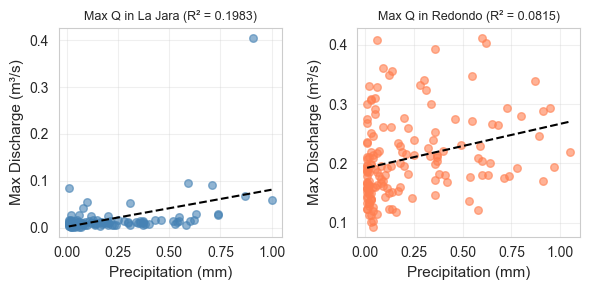

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
sns.set_style("whitegrid")

# filter out rows with temperatures < 32°F (potential snow)
lajara_daily_filtered = lajara_daily[lajara_daily['avg_temp'] >= 32]  # adjust column name as needed
redondo_daily_filtered = redondo_daily[redondo_daily['avg_temp'] >= 32]  # adjust column name as needed

# La Jara
valid_lajara = lajara_daily_filtered[['lajara_max', 'total_precip']].dropna()
valid_lajara = valid_lajara[valid_lajara['total_precip'] > 0]  # exclude zero precip
ax = axes[0]
ax.scatter(valid_lajara['total_precip'], valid_lajara['lajara_max'], alpha=0.6, s=30, color='steelblue')
slope, intercept, r_value, p_value, std_err = linregress(valid_lajara['total_precip'], valid_lajara['lajara_max'])
x_line = np.array([valid_lajara['total_precip'].min(), valid_lajara['total_precip'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Max Discharge (m³/s)', fontsize=11)
ax.set_title(f'Max Q in La Jara (R² = {r_value**2:.4f})', fontsize=9)
ax.grid(True, alpha=0.3)

# Redondo
valid_redondo = redondo_daily_filtered[['redondo_max', 'total_precip']].dropna()  # adjust column name as needed
valid_redondo = valid_redondo[valid_redondo['total_precip'] > 0]  # exclude zero precip
ax = axes[1]
ax.scatter(valid_redondo['total_precip'], valid_redondo['redondo_max'], alpha=0.6, s=30, color='coral')
slope, intercept, r_value, p_value, std_err = linregress(valid_redondo['total_precip'], valid_redondo['redondo_max'])
x_line = np.array([valid_redondo['total_precip'].min(), valid_redondo['total_precip'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Max Discharge (m³/s)', fontsize=11)
ax.set_title(f'Max Q in Redondo (R² = {r_value**2:.4f})', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Plots by year

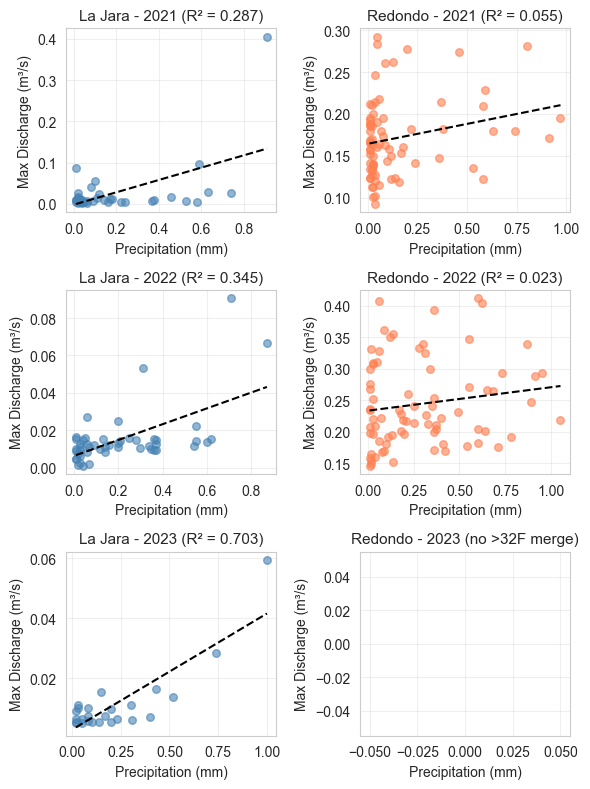

In [107]:
fig, axes = plt.subplots(3, 2, figsize=(6, 8))
sns.set_style("whitegrid")

years = [2021, 2022, 2023]
rivers = [('La Jara', lajara_daily, 'lajara_max', 'steelblue'),
          ('Redondo', redondo_daily, 'redondo_max', 'coral')]

for row, year in enumerate(years):
    for col, (river_name, river_data, discharge_col, color) in enumerate(rivers):
        ax = axes[row, col]
        
        # Filter by year and temperature >= 32°F
        year_data = river_data[(river_data.index.year == year) & (river_data['avg_temp'] >= 32)]
        valid_data = year_data[[discharge_col, 'total_precip']].dropna()
        valid_data = valid_data[valid_data['total_precip'] > 0]  # exclude zero precip
        
        if len(valid_data) > 1 and valid_data['total_precip'].min() != valid_data['total_precip'].max():
            # Scatter plot
            ax.scatter(valid_data['total_precip'], valid_data[discharge_col], alpha=0.6, s=30, color=color)
            
            # Linear regression
            slope, intercept, r_value, p_value, std_err = linregress(valid_data['total_precip'], valid_data[discharge_col])
            x_line = np.array([valid_data['total_precip'].min(), valid_data['total_precip'].max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5)
            
            ax.set_xlabel('Precipitation (mm)', fontsize=10)
            ax.set_ylabel('Max Discharge (m³/s)', fontsize=10)
            ax.set_title(f'{river_name} - {year} (R² = {r_value**2:.3f})', fontsize=11)
        else:
            # Just scatter plot without regression
            ax.scatter(valid_data['total_precip'], valid_data[discharge_col], alpha=0.6, s=30, color=color)
            ax.set_xlabel('Precipitation (mm)', fontsize=10)
            ax.set_ylabel('Max Discharge (m³/s)', fontsize=10)
            ax.set_title(f'{river_name} - {year} (no >32F merge)', fontsize=11)
        
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()